In [1]:
# Wrapper do BLAST+ para Python
import subprocess
import pandas as pd
import io
import os

def rodar_blast_local(sequencia_fasta, nome_db, output_file="temp_blast.txt"):
    """
    Roda o BLASTn-short para uma sequência contra um banco local.
    Retorna um DataFrame com os hits.
    """
    # 1. Salva a sequência do gene num arquivo temporário
    with open("temp_query.fasta", "w") as f:
        f.write(sequencia_fasta)
        
    # 2. Comando do BLAST (Otimizado para RNAi/Short reads)
    # Nota: Ajuste o caminho do 'blastn' se não estiver no PATH
    cmd = [
        "blastn",
        "-task", "blastn-short",
        "-query", "temp_query.fasta",
        "-db", nome_db,
        "-outfmt", "6 qseqid sseqid pident length qstart qend evalue",
        "-dust", "no", # Desliga filtro de complexidade para achar tudo
        "-word_size", "7",
        "-evalue", "1000", # Permite hits curtos
        "-perc_identity", "100" # Apenas matches idênticos (Risco RNAi)
    ]
    
    # 3. Executa
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    # 4. Processa o resultado em Pandas
    if result.returncode != 0:
        print(f"Erro no BLAST: {result.stderr}")
        return pd.DataFrame()
    
    colunas = ["qseqid", "sseqid", "pident", "length", "qstart", "qend", "evalue"]
    
    # Se não houve hits, retorna vazio
    if not result.stdout:
        return pd.DataFrame(columns=colunas)
        
    df = pd.read_csv(io.StringIO(result.stdout), sep="\t", names=colunas)
    
    # Filtrar apenas hits relevantes para RNAi (>= 21pb)
    df_filtrado = df[df['length'] >= 21].copy()
    
    return df_filtrado

In [2]:
# Gerador de Gráficos de Alinhamento
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plotar_risco_rnai(df_hits, tamanho_gene, titulo_gene, nome_organismo):
    """
    Cria uma visualização gráfica de onde os hits caem no gene.
    """
    fig, ax = plt.subplots(figsize=(12, 3))
    
    # 1. Desenha o Gene (Barra Cinza de fundo)
    ax.add_patch(patches.Rectangle((0, 0.4), tamanho_gene, 0.2, color='lightgray', label='Gene do Fungo'))
    
    # 2. Desenha os Conflitos (Barras Vermelhas)
    # Se houver hits, plota cada um
    if not df_hits.empty:
        for _, row in df_hits.iterrows():
            start = min(row['qstart'], row['qend'])
            width = abs(row['qend'] - row['qstart']) + 1
            
            # Adiciona retângulo vermelho nas coordenadas do hit
            ax.add_patch(patches.Rectangle((start, 0.4), width, 0.2, color='red', alpha=0.7))
            
        ax.text(0, 0.7, f"ALERTA: {len(df_hits)} regiões de conflito detectadas!", color='darkred', weight='bold')
    else:
        ax.text(0, 0.7, "VERDE: Nenhuma homologia encontrada (Seguro).", color='green', weight='bold')

    # Estilização
    ax.set_xlim(0, tamanho_gene)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Posição no Gene (pb)")
    ax.set_title(f"Mapa de Risco: {titulo_gene} vs. {nome_organismo}")
    
    # Legenda inteligente (só adiciona 'Risco' se tiver hits)
    handles, labels = ax.get_legend_handles_labels()
    if not df_hits.empty:
        patch_risk = patches.Patch(color='red', label='Sequência Idêntica (Off-target)')
        handles.append(patch_risk)
        
    ax.legend(handles=handles, loc='upper right')
    
    plt.tight_layout()
    plt.show()

In [3]:
from Bio import SeqIO

c_abs_CDS_file = '../c_abscissum_data/ncbi_dataset/data/GCA_023376855.1/cds_from_genomic.fna'
c_abs_genes = SeqIO.index(c_abs_CDS_file, "fasta")

--- INICIANDO ANÁLISE DE RISCO MULTI-ESPÉCIE ---

ANALISANDO: Scytalone Dehydratase (576 pb)
 -> Verificando contra: db_citrus...


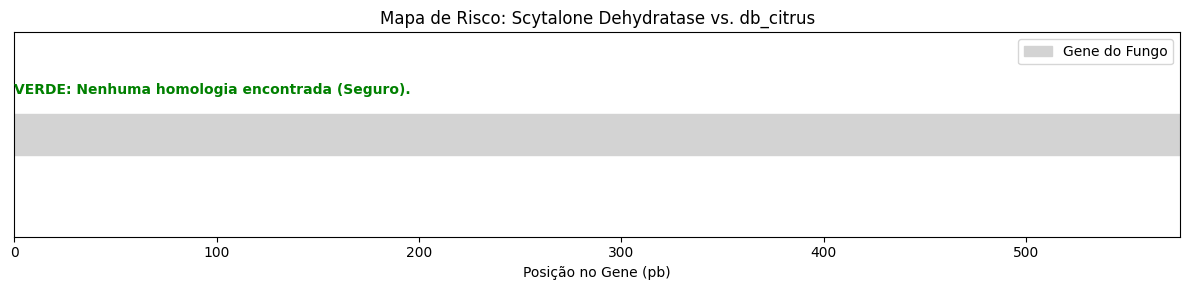

 -> Verificando contra: db_human...


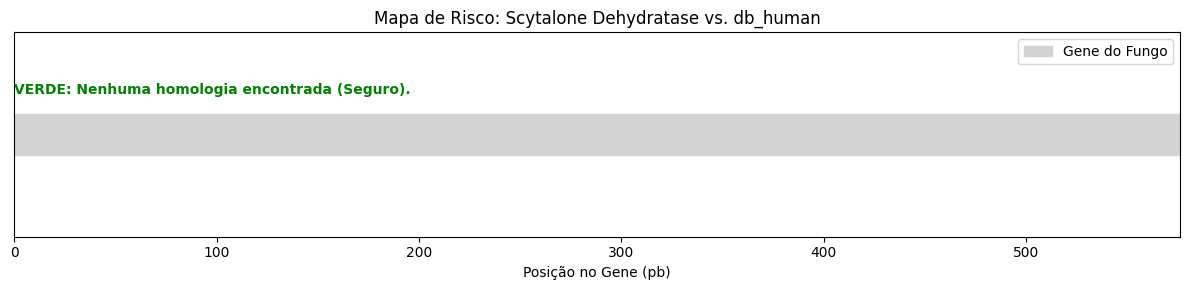

 -> Verificando contra: db_bee...


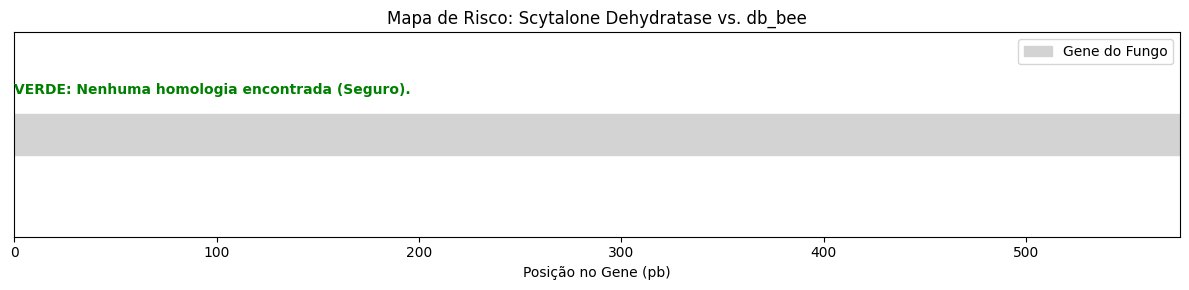



ANALISANDO: Actina (Controle) (1347 pb)
 -> Verificando contra: db_citrus...


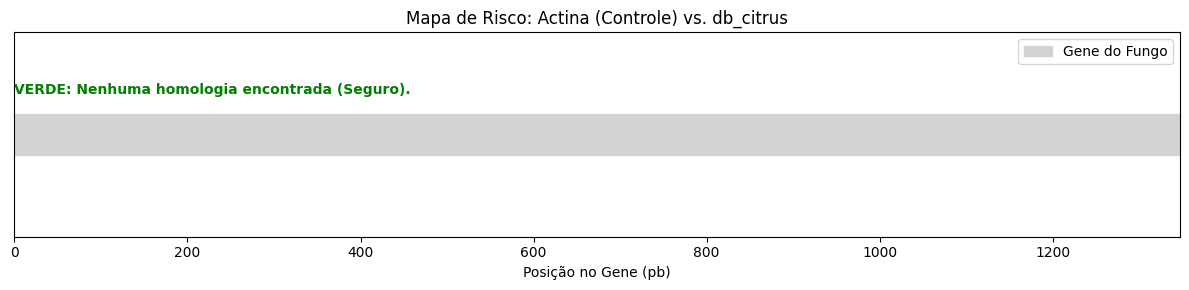

 -> Verificando contra: db_human...


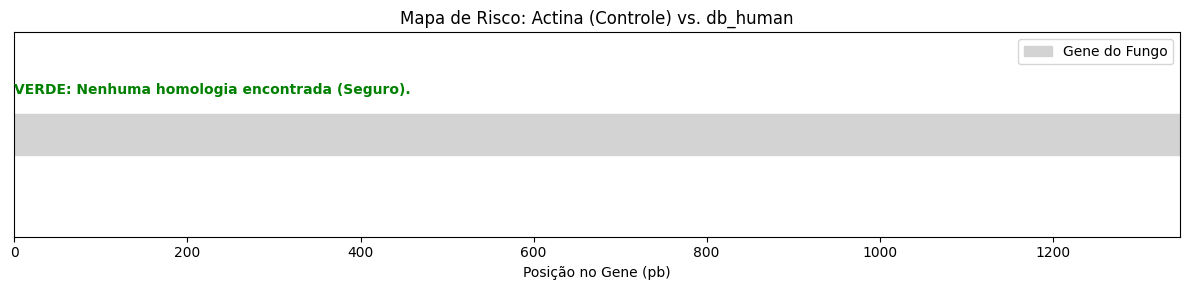

 -> Verificando contra: db_bee...


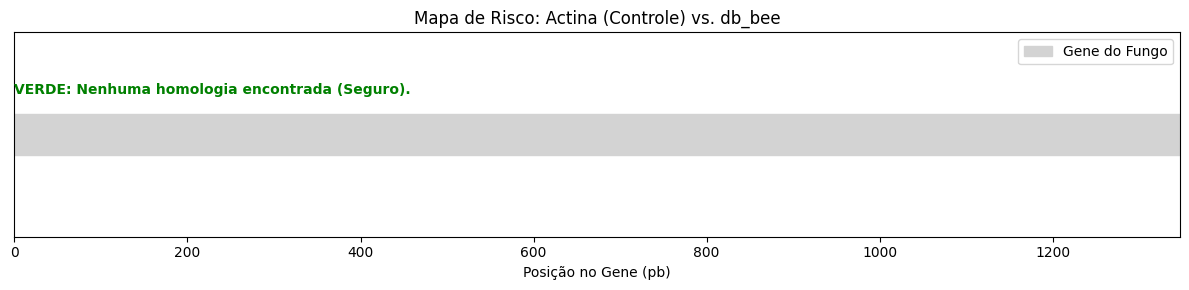

In [4]:
# Execução em Lote (Batch)

# 1. Seus Genes Candidatos (Exemplo: dicionário ID -> Sequência)
# Num cenário real, você leria isso do arquivo 'genes_candidatos.fasta' usando SeqIO
genes_para_teste = {
    "Scytalone Dehydratase": str(c_abs_genes["lcl|SDAQ01000016.1_cds_KAI3555617.1_3992"].seq),
    "Actina (Controle)": str(c_abs_genes["lcl|SDAQ01000033.1_cds_KAI3553165.1_6722"].seq)
}

# 2. Seus Bancos de Organismos (Nomes que você deu no makeblastdb)
bancos_offtarget = ["db_citrus", "db_human", "db_bee"] 

print(f"--- INICIANDO ANÁLISE DE RISCO MULTI-ESPÉCIE ---\n")

for nome_gene, sequencia in genes_para_teste.items():
    tamanho = len(sequencia)
    print(f"==================================================")
    print(f"ANALISANDO: {nome_gene} ({tamanho} pb)")
    print(f"==================================================")
    
    # Formata como FASTA para o BLAST
    fasta_formatado = f">{nome_gene}\n{sequencia}"
    
    for db in bancos_offtarget:
        print(f" -> Verificando contra: {db}...")
        
        # 1. Roda BLAST
        df_resultado = rodar_blast_local(fasta_formatado, db)
        
        # 2. Gera o Gráfico
        plotar_risco_rnai(df_resultado, tamanho, nome_gene, db)
        
    print("\n")